In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

In [2]:
# Data loading

dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,...,14815,14816,14817,14825,14817,14818,14823,14821,14824,14821,14824,14815,14817,14823,14820,14816,14818,14824,14815,14820,14818,14818,14818,14816,14824,14822,14823,14816,14818,14823,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,14823,14823,14822,14824,14827,14824,14822,14823,14823,14824,14824,14820,14824,14823,14822,14818,14828,14819,14824,14823,14820,14821,14822,14817,14824,14821,14823,14822,14819,14825,...,14818,14820,14824,14816,14819,14828,14820,14821,14824,14817,14818,14819,14820,14820,14822,14826,14824,14815,14819,14820,14820,14821,14819,14825,14822,14819,14824,14827,14817,14824,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,14823,14823,14823,14824,14819,14820,14823,14821,14820,14822,14818,14819,14820,14824,14822,14822,14820,14820,14824,14822,14820,14822,14823,14823,14822,14815,14820,14824,14827,14827,...,14819,14818,14824,14821,14820,14819,14824,14825,14818,14820,14820,14816,14815,14821,14820,14827,14819,14819,14824,14821,14819,14822,14822,14820,14820,14822,14822,14826,14823,14822,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,14820,14824,14826,14821,14818,14826,14820,14824,14824,14822,14823,14820,14819,14820,14820,14823,14820,14824,14823,14820,14823,14825,14827,14822,14818,14828,14824,14828,14820,14822,...,14822,14820,14817,14827,14819,14826,14824,14823,14823,14822,14824,14823,14823,14823,14820,14821,14823,14822,14824,14822,14820,14820,14820,14825,14820,14822,14823,14821,14824,14824,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,14822,14825,14822,14823,14820,14823,14823,14821,14820,14826,14820,14818,14819,14821,14822,14825,14820,14823,14823,14817,14823,14827,14823,14820,14817,14823,14828,14818,14823,14825,...,14820,14816,14819,14824,14819,14819,14820,14820,14823,14819,14820,14822,14823,14822,14817,14821,14820,14821,14817,14824,14820,14817,14820,14817,14823,14823,14820,14823,14820,14819,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


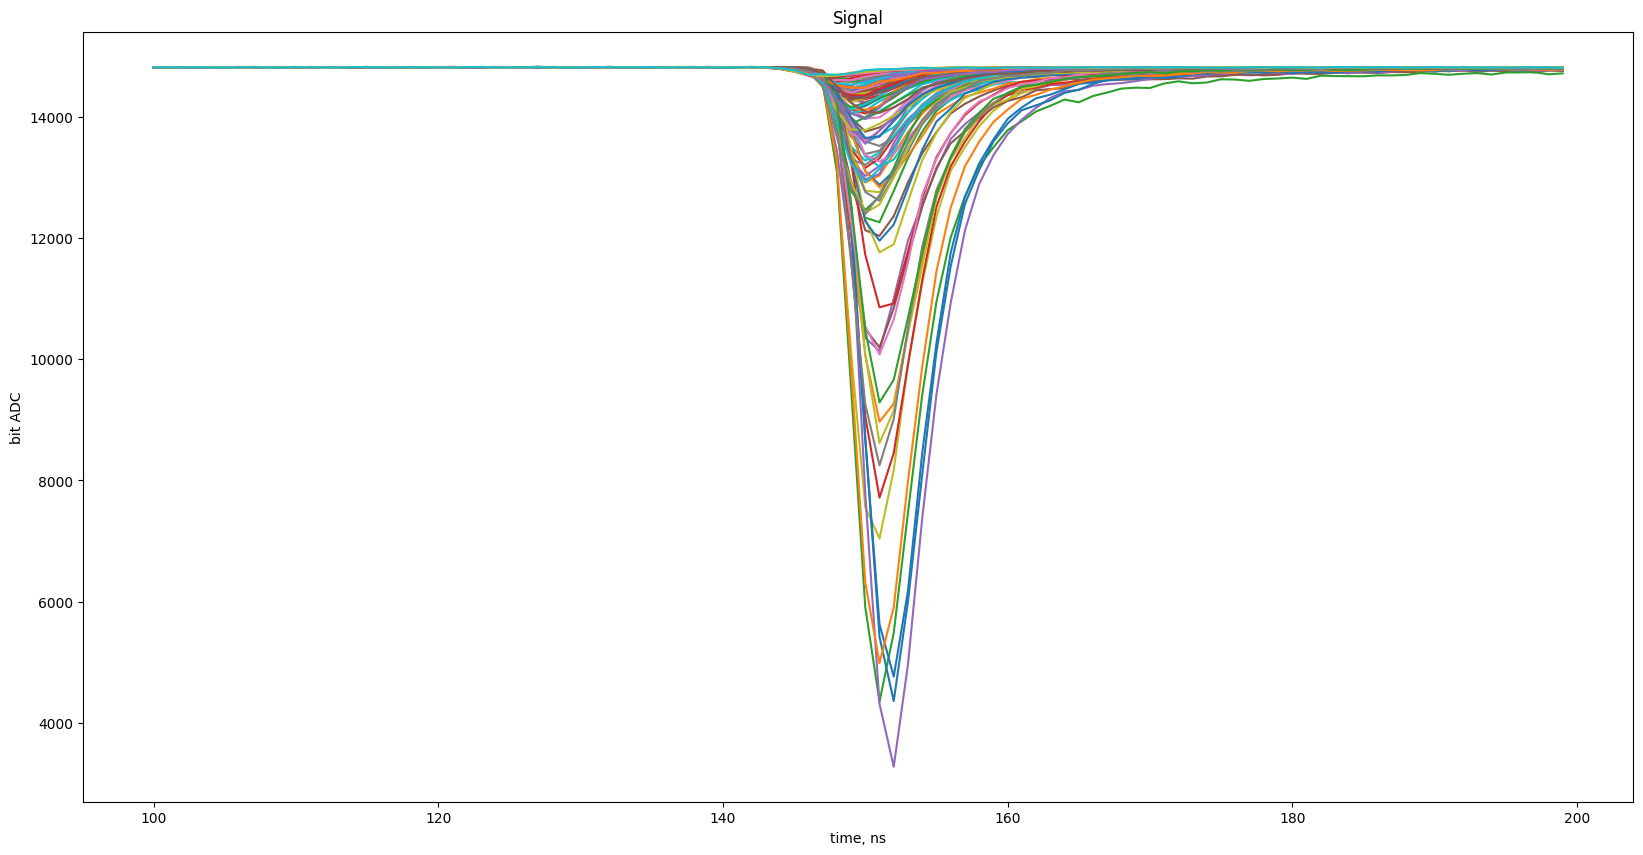

In [3]:
N=range(0,100)
ax = dataset.T[N][100:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

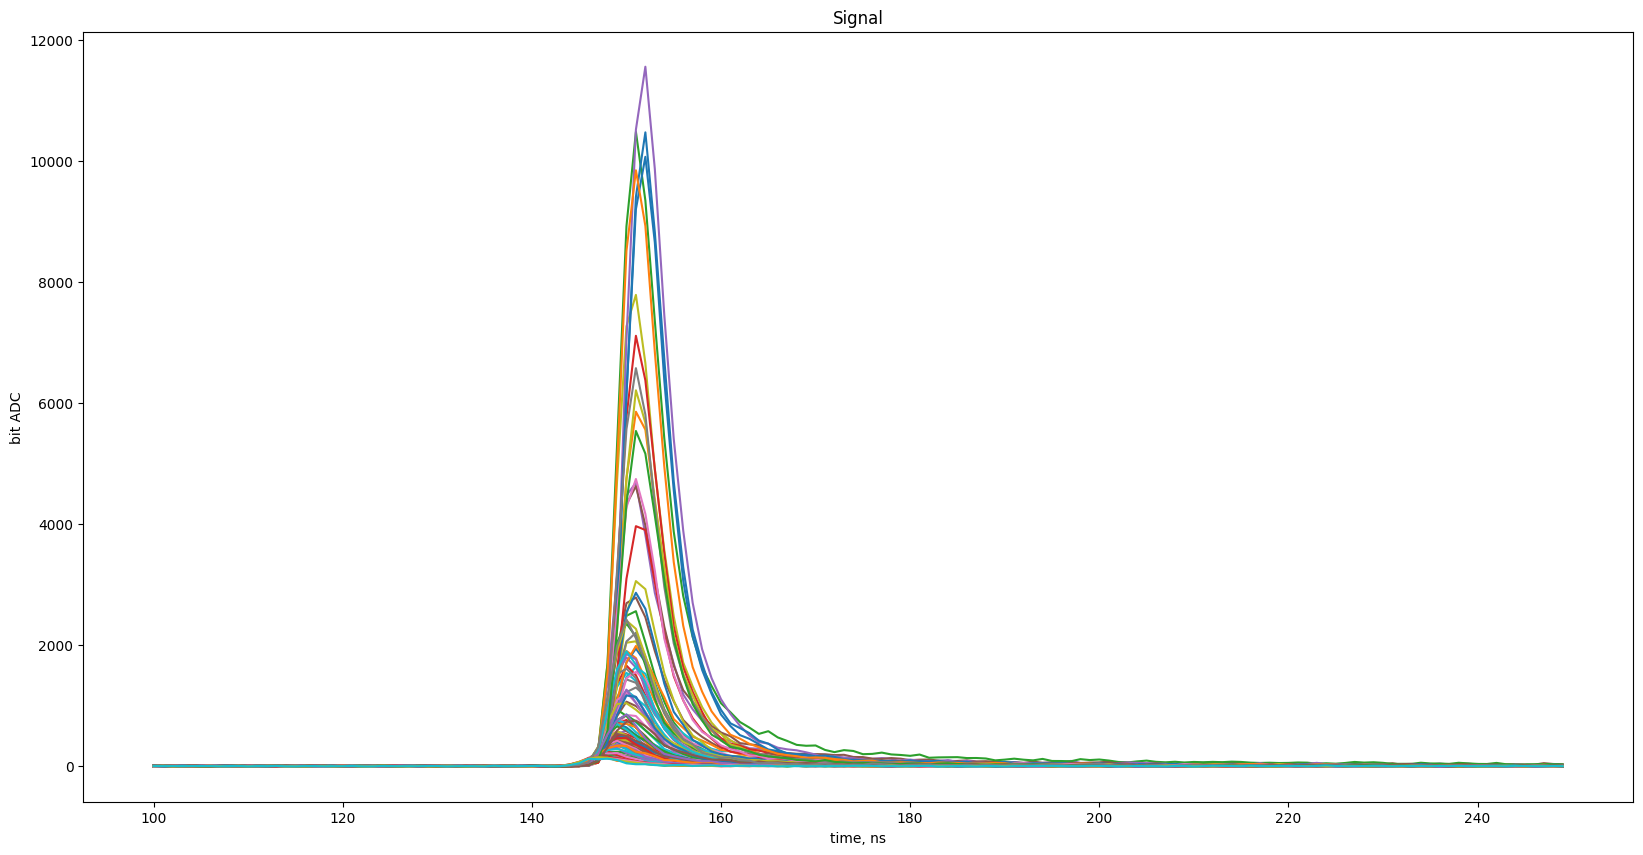

In [4]:
ax = (2**14-dataset.T[N]-1560)[100:250].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

In [5]:
raw_data = (2**14-dataset.T-1560).T

$signal_j = Raw Data_j [j_{max}; j_{3*\sigma_j}]$, где $j_{max}$ - время достижения максимума, а $j_{3*\sigma_j}$ - время достижения отставания в три стандартных отклонения от 0.

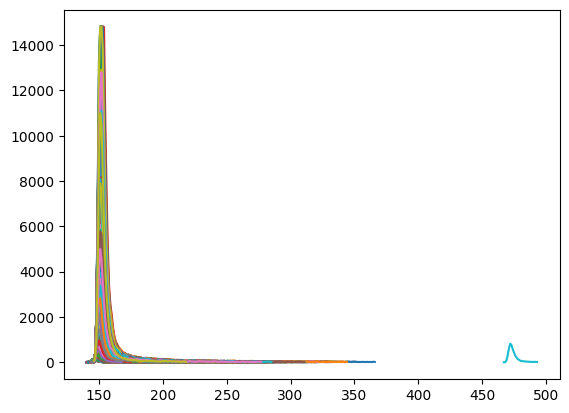

In [7]:
shift = 5
signals = []
for i in range(raw_data.shape[0]):
    data = raw_data.iloc[i]
    mean = data[:50].mean()
    std = data[:50].std()
    max_idx = np.argmax(data)
    start_t = max_idx-shift
    data = data[start_t:]
    data = data[:np.argmax(data[shift + 1:] - mean <= 3*std) + shift + 1]
    signals.append(data.to_numpy())
    end_t = start_t + len(data)
    plt.plot(np.arange(start_t, end_t), signals[-1])
plt.show()

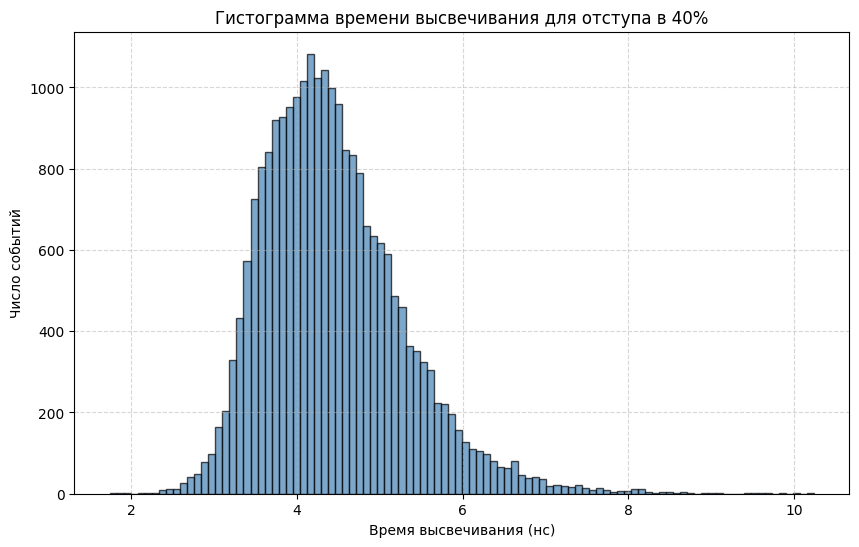

Обработано событий: 23474 из 23479
Среднее время: 4.43 нс
Медиана: 4.32 нс
Стандартное отклонение: 0.85 нс


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

N_percent = 40
time_step_ns = 1.0
peak_search_start = 100

df = raw_data
time_axis = np.arange(df.shape[1]) * time_step_ns

taus = []

def exp_decay(t, tau):
    return np.exp(-t / tau)

for idx in range(5, len(df)):
    signal = df.iloc[idx].values
    # print(signal)
    peak_idx = np.argmax(signal)
    peak_amp = signal[peak_idx]
    target_amp = (1 - N_percent / 100.0) * peak_amp
    # print(peak_amp, target_amp)
    signal = signal[peak_idx:]
    # signal = signal[:np.argmax(signal <= target_amp)] / peak_amp
    signal = signal[:10] / peak_amp
    # plt.plot(np.arange(signal.shape[0]), signal)
    
    if not len(signal):
        print("skip ", idx)
        continue
    # print(signal)
    popt, pcov = curve_fit(exp_decay, np.arange(signal.shape[0]), signal, p0=(1.0), maxfev=10000)
    # plt.plot(np.arange(signal.shape[0]), signal)
    # plt.plot(np.arange(signal.shape[0]), exp_decay(np.arange(signal.shape[0]), popt[0]))
    taus.append(popt[0])
    
taus = np.array(taus)
# filtering
plt.figure(figsize=(10, 6))
plt.hist(taus, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Время высвечивания (нс)')
plt.ylabel('Число событий')
plt.title(f'Гистограмма времени высвечивания для отступа в {N_percent}%')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Статистика
print(f"Обработано событий: {len(taus)} из {len(df)}")
print(f"Среднее время: {np.mean(taus):.2f} нс")
print(f"Медиана: {np.median(taus):.2f} нс")
print(f"Стандартное отклонение: {np.std(taus):.2f} нс")

PSD

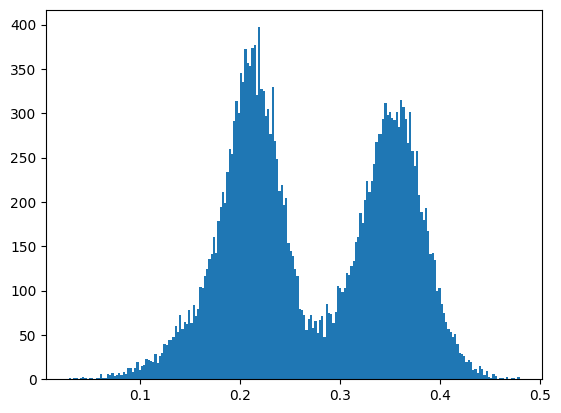

In [84]:
short_gate = 10
psd = []
# попробуем методом трапеции без аппроксимации экспонентой
for signal in signals:
    long = np.trapezoid(signal)
    short = np.trapezoid(signal[:short_gate])
    psd.append(1 - short / long)
psd = np.asarray(psd)
plt.hist(psd, bins=200)
plt.show()

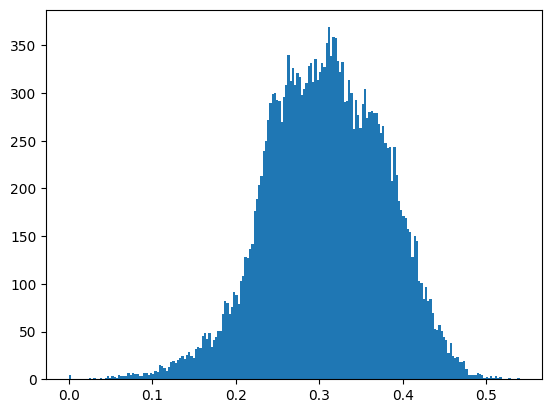

In [89]:
short_gate = 6
psd2 = []
# через аппроксимацию
for signal in signals:
    ts = np.arange(signal.shape[0] - 5)
    m = np.max(signal)
    popt, pcov = curve_fit(exp_decay, ts, signal[5:]/m, p0=(1.0), maxfev=10000)
    tau = popt[0]
    long = tau * (exp_decay(ts[0], tau) - exp_decay(ts[-1], tau))
    short = tau * (exp_decay(ts[0], tau) - exp_decay(ts[min(short_gate - 1, len(ts) - 1)], tau))
    psd2.append(1 - short / long)
plt.hist(psd2, bins=200)
plt.show()

Amplitude and volume

In [16]:
ampls = np.asarray(list(map(np.max, signals)))
volumes = np.asarray(list(map(np.trapezoid, signals)))

In [17]:
mask = ampls > 14000
high_ampl_idx = np.where(ampls > 14000)[0]

In [18]:
ampls = ampls[~mask]
volumes = volumes[~mask]
psd_filtered = psd[~mask]

In [19]:
X = np.vstack([volumes, ampls])

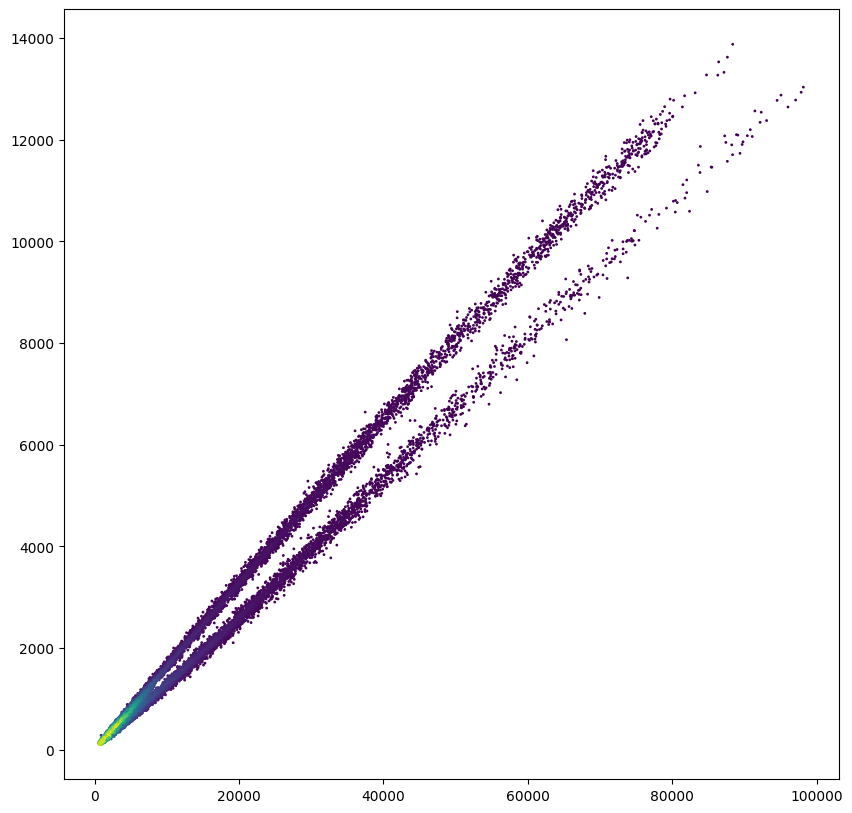

In [20]:
z = gaussian_kde(X)(X)
plt.figure(figsize=(10, 10))
plt.scatter(volumes, ampls, c=z, s=1)
plt.show()

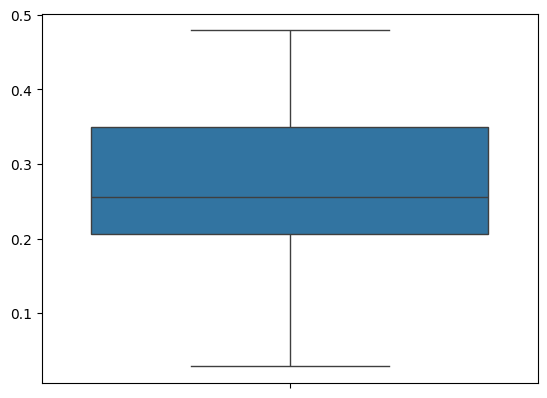

In [21]:
import seaborn as sns 
sns.boxplot(data=np.asarray(psd))
plt.show()

Clustering.

In [22]:
X = X.T

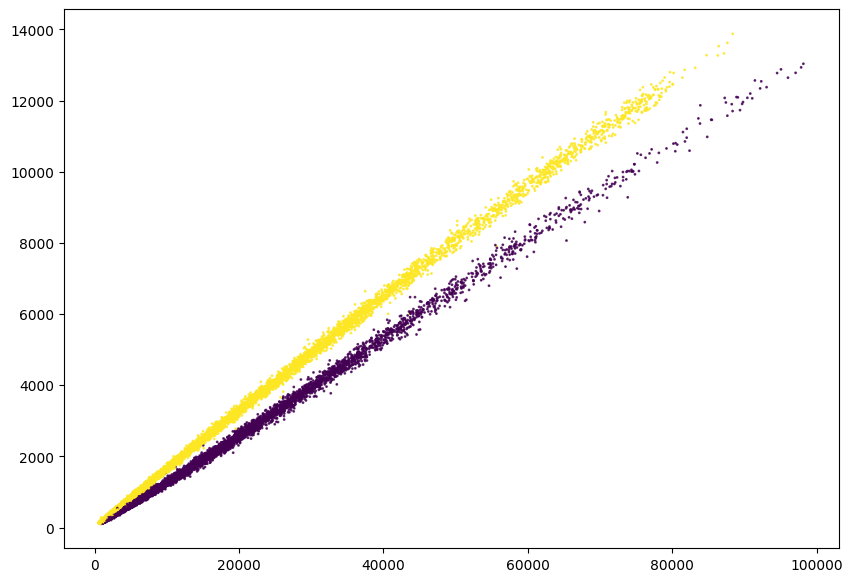

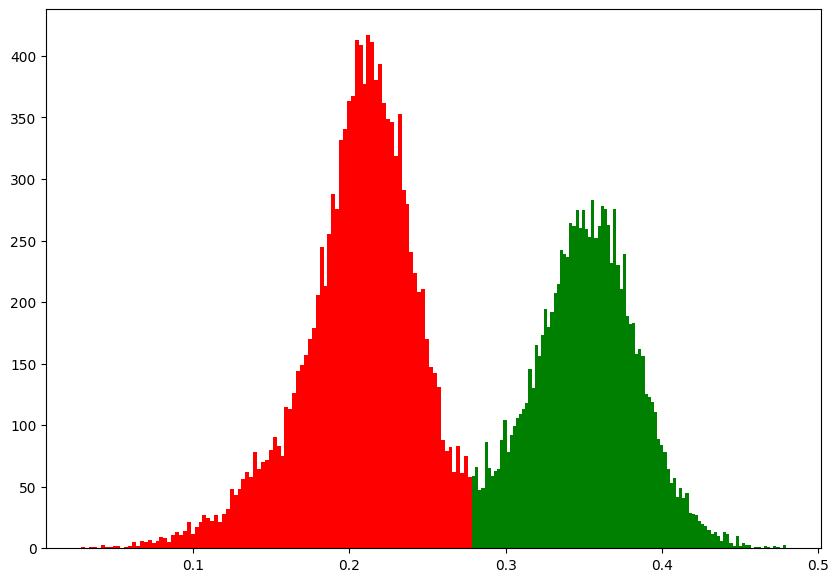

In [106]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, algorithm="elkan")
y_pred = kmeans.fit_predict(np.asarray(psd_filtered).reshape(-1, 1))
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=1, alpha=0.8)
plt.show()
plt.figure(figsize=(10, 7))
plt.hist(psd_filtered[y_pred == 0], color='g', bins=100)
plt.hist(psd_filtered[y_pred == 1], color='r', bins=100)
plt.show()

In [26]:
y_pred = np.insert(y_pred, high_ampl_idx, 2)

In [27]:
solution = pd.DataFrame(y_pred, columns=["cluster"]).sort_values(by="cluster")

In [28]:
solution.to_csv("solution.csv", index_label="index")

In [52]:
pca = PCA(n_components=1)
pced = pca.fit_transform(X)

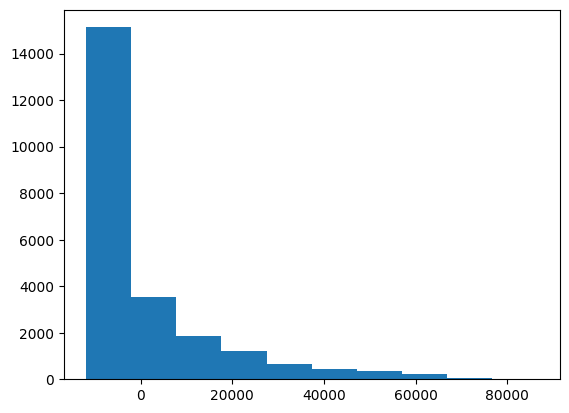

In [58]:
pced
plt.hist(pced)
plt.show()

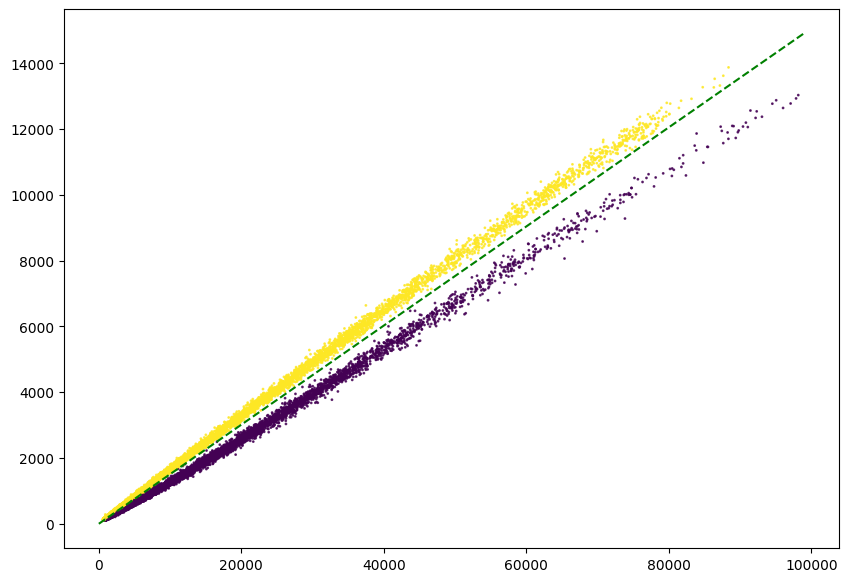

In [118]:
plt.figure(figsize=(10, 7))
plt.plot([0.0, pca.components_[0][0]*100_000], [0.0, pca.components_[0][1]*100_000], linestyle='--', c='g')
y_pred = np.asarray([1 + np.sign(np.linalg.cross(np.append(pca.components_[0], 0), np.append(v, 0))[-1]) for v in X], dtype=int) / 2
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=1, alpha=0.8)
plt.show()

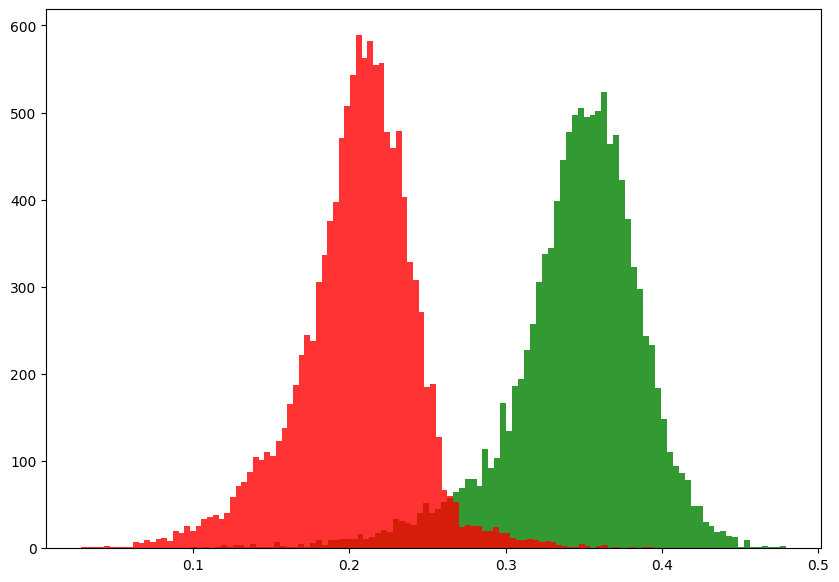

In [119]:
plt.figure(figsize=(10, 7))
plt.hist(psd_filtered[y_pred == 0], color='g', bins=100, alpha=0.8)
plt.hist(psd_filtered[y_pred == 1], color='r', bins=100, alpha=0.8)
plt.show()

In [120]:
y_pred = np.insert(y_pred, high_ampl_idx, 2)
solution = pd.DataFrame(y_pred, columns=["cluster"], dtype=int).sort_values(by="cluster")
solution.to_csv("solution.csv", index_label="index")

In [121]:
solution

,cluster
21,0
25,0
27,0
12,0
14,0
...,...
9194,2
11295,2
798,2
17799,2
